# 05 · Numerical integration

**Problem.** A machine's power draw during an 8-hour shift is logged every 30 minutes. How much
energy did it use, and how much does the answer depend on the logging interval and the rule used?

To measure errors exactly we use a known smooth profile (start-up surge, production cycle,
lunch break):
$$P(t) = 40 + 25\sin^2(\pi t/8) + 30\,e^{-(t-0.5)^2/0.08} - 20\,e^{-(t-4)^2/0.1}\quad\text{kW}.$$

**What you will learn**

- integrate sampled data with the trapezoid rule, Simpson's rule and splines
- implement composite Simpson's rule
- measure an order of accuracy from a log-log plot
- recognise when the sampling interval, not the rule, limits the accuracy

**Before you start:** notebooks 00 and 04; Taylor series (for why errors scale with h)  ·  **Time:** about 45-60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import integrate
from scipy.integrate import quad

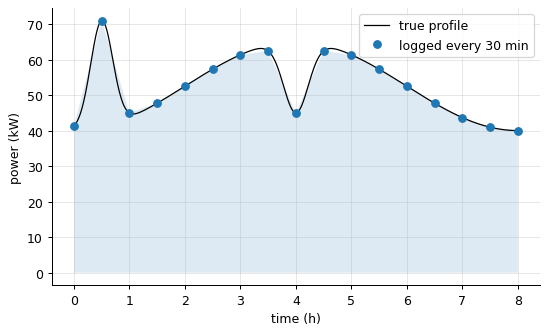

exact energy 423.736 kWh


In [2]:
def power(t):
    return 40 + 25*np.sin(np.pi*t/8)**2 + 30*np.exp(-(t-0.5)**2/0.08) - 20*np.exp(-(t-4)**2/0.1)

E_exact = quad(power, 0, 8, epsabs=1e-13, limit=200)[0]     # kWh, reference
t_log = np.arange(0, 8.01, 0.5)
P_log = power(t_log)
tt = np.linspace(0, 8, 800)
plt.plot(tt, power(tt), "k", lw=1, label="true profile")
plt.plot(t_log, P_log, "o", label="logged every 30 min")
plt.fill_between(t_log, P_log, alpha=0.15, step=None)
plt.xlabel("time (h)"); plt.ylabel("power (kW)"); plt.legend(); plt.show()
print(f"exact energy {E_exact:.3f} kWh")

In [3]:
from engmath.interpolate import CubicSpline
rules = {"trapezoid": integrate.trapezoid(P_log, t_log),
         "Simpson":   integrate.simpson(P_log, t_log),
         "spline":    CubicSpline(t_log, P_log).integral()}
for k, v in rules.items():
    print(f"{k:<10} {v:8.3f} kWh   error {v - E_exact:+.3f} kWh ({100*(v/E_exact-1):+.2f} %)")

trapezoid   424.346 kWh   error +0.610 kWh (+0.14 %)
Simpson     431.803 kWh   error +8.067 kWh (+1.90 %)
spline      426.310 kWh   error +2.573 kWh (+0.61 %)


## Inside the algorithm: Simpson's rule
Simpson's rule fits a parabola through each consecutive triple of equally spaced points; integrating the
parabola gives the weights $\tfrac{h}{3}(1, 4, 1)$. Added up over the whole range, the weights become
$\tfrac{h}{3}(1, 4, 2, 4, \ldots, 2, 4, 1)$:

In [4]:
def simpson_by_hand(f, a, b, n):
    # composite Simpson's rule with n (even) equal intervals
    x = np.linspace(a, b, n + 1)
    w = np.ones(n + 1)
    w[1:-1:2] = 4
    w[2:-1:2] = 2
    return (b - a) / n / 3 * np.sum(w * f(x))

for n in (16, 64):
    print(f"n = {n}: by hand {simpson_by_hand(power, 0, 8, n):.10f}, library {integrate.composite(power, 0, 8, n, 'simpson'):.10f}")

n = 16: by hand 431.8029232372, library 431.8029232372
n = 64: by hand 423.7343875756, library 423.7343875756


The library version also handles *unevenly* spaced data, giving each pair of intervals its own parabola:

In [5]:
show_source(integrate.simpson)

def simpson(y, x=None, dx: float = 1.0) -> float:
    """Composite Simpson's rule (error O(h^4)). Unequal spacing is handled pairwise; with an odd
    number of intervals the last interval uses the 3-point parabola through the final points."""
    y = np.asarray(y, float)
    x = np.arange(y.size) * dx if x is None else np.asarray(x, float)
    if y.size < 3:
        raise ValueError("Simpson's rule needs at least 3 points.")
    h = np.diff(x)
    total = 0.0
    n_int = h.size
    last = n_int - 1 if n_int % 2 else n_int
    for i in range(0, last, 2):
        h0, h1 = h[i], h[i + 1]
        total += (h0 + h1) / 6 * ((2 - h1 / h0) * y[i] + (h0 + h1) ** 2 / (h0 * h1) * y[i + 1]
                                  + (2 - h0 / h1) * y[i + 2])
    if n_int % 2:  # integrate the last interval with the parabola through the last three points
        h0, h1 = h[-2], h[-1]
        a = (2 * h1**2 + 3 * h0 * h1) / (6 * (h0 + h1))
        b = (h1**2 + 3 * h0 * h1) / (6 * h0)
        c = -h1**3 / (6 * h0 * (h0 + h1))
        total += a * y[-1] + b * y[-2] + c * y[-3]
    return float(total)

Surprise: Simpson's rule, "more accurate" in textbooks, is the *worst* here. Higher-order rules assume
the function is smooth on the scale of the sampling interval, but the start-up surge lasts only
about half an hour and is sampled by a single point - the parabolas then over- or undershoot. **The
sampling interval, not the integration rule, limits the accuracy here.** Integration rules cannot
recover information that was never measured; order-of-accuracy statements only hold once the
data resolve the signal.

## Order of accuracy
For a smooth integrand the error of a rule behaves as $C h^p$. On a log-log plot the slope is the
order $p$: trapezoid and midpoint 2, Simpson 4, while Gauss-Legendre converges faster than any
power.

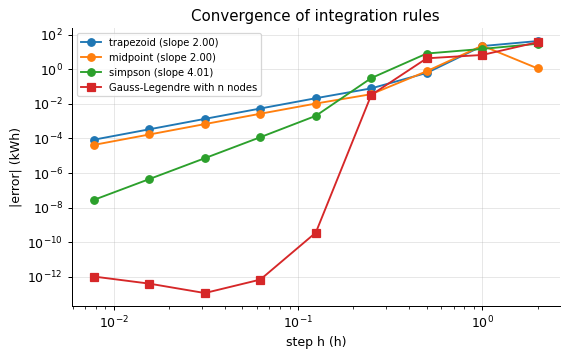

In [6]:
ns = 2**np.arange(2, 11)
fig, ax = plt.subplots()
for rule in ("trapezoid", "midpoint", "simpson"):
    err = [abs(integrate.composite(power, 0, 8, n, rule) - E_exact) for n in ns]
    slope = np.polyfit(np.log(8/ns[-4:]), np.log(err[-4:]), 1)[0]
    ax.loglog(8/ns, err, "o-", label=f"{rule} (slope {slope:.2f})")
gl = [abs(integrate.gauss_legendre(power, 0, 8, n) - E_exact) for n in ns]
ax.loglog(8/ns, np.maximum(gl, 1e-15), "s-", label="Gauss-Legendre with n nodes")
ax.set(xlabel="step h (h)", ylabel="|error| (kWh)", title="Convergence of integration rules")
ax.legend(fontsize=8); plt.show()

**Romberg integration** extrapolates trapezoid results at $h, h/2, h/4, \ldots$ to $h \to 0$:

In [7]:
R = integrate.romberg(power, 0, 8, 8)
print("Romberg diagonal:", np.round(np.diag(R), 8))
print(f"error of best estimate: {abs(R[-1,-1] - E_exact):.1e} kWh")

Romberg diagonal: [325.27243203 348.42414401 397.26460054 410.03726625 433.79812602
 422.65095213 423.77428755 423.73593795]
error of best estimate: 4.6e-04 kWh


## Running totals: cumulative integration
A flow meter reports the filling rate of a tank; the volume is the running integral.

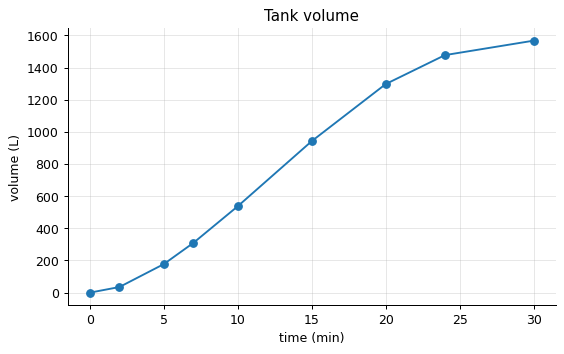

total volume 1568 L


In [8]:
t_min = np.array([0, 2, 5, 7, 10, 15, 20, 24, 30])          # uneven logging times
Q_Lmin = np.array([0, 35, 60, 72, 80, 82, 60, 30, 0])       # L/min
V = integrate.cumulative_trapezoid(Q_Lmin, t_min)
plt.plot(t_min, V, "o-"); plt.xlabel("time (min)"); plt.ylabel("volume (L)"); plt.title("Tank volume"); plt.show()
print(f"total volume {V[-1]:.0f} L")

## Exercises
1. How often must the power be logged for the trapezoidal energy estimate to be within 0.5 %?
2. Show that Simpson's rule on *equally* spaced points is exact for cubics, but not on unequal
   spacing. (Integrate $t^3$ on both kinds of grid.)
3. The logged power has random measurement noise of ±1 kW (standard deviation). Use Monte Carlo to
   find the resulting uncertainty in the energy. Is it larger or smaller than the sampling error?
4. **Implement it yourself:** Boole's rule applies the weights $\tfrac{2h}{45}(7, 32, 12, 32, 7)$ to groups of four intervals. Implement it, measure its order on the power profile (theory: 6), and explain why it still cannot capture the start-up surge from 30-minute data.